# Fit the seed amplitude to a target island

Gradients turn a simulation into an optimization target. This tutorial
finds the seed perturbation amplitude that produces a chosen island size,
using six gradient-descent steps. The committed outputs ran on a laptop CPU
in under twenty seconds.

Read [differentiate a simulation](03_gradients.ipynb) first: it validates
the gradient this tutorial relies on.

In [1]:
import math

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

from mhx.equations.reduced_mhd import reduced_mhd_rhs_spectral, to_spectral_state
from mhx.grids import CartesianGrid
from mhx.physics import PeriodicDoubleHarrisEquilibrium
from mhx.state import ReducedMHDParams, ReducedMHDState
from mhx.time_integrators import evolve_rk4

grid = CartesianGrid(
    shape=(32, 32),
    lower=(0.0, 0.0),
    upper=(2.0 * math.pi, 2.0 * math.pi),
)
x, y = grid.mesh()
base = PeriodicDoubleHarrisEquilibrium(width=0.4).initial_state(grid)
pattern = jnp.cos(2.0 * x) * jnp.cos(y)
params = ReducedMHDParams(resistivity=5.0e-3, viscosity=5.0e-3)

## A differentiable forward model

The seed enters the initial state as $\psi_0 = \psi_{\mathrm{eq}} +
\varepsilon\cos(2x)\cos(y)$, built with plain array operations so the
whole map from $\varepsilon$ to the final island amplitude differentiates.
The island metric is the magnitude of the seeded Fourier mode at the final
time.

In [2]:
def island_amplitude(epsilon):
    psi0 = base.psi + epsilon * pattern
    state0 = to_spectral_state(ReducedMHDState(psi=psi0, omega=base.omega))

    def rhs(state):
        return reduced_mhd_rhs_spectral(state, params, lengths=grid.lengths)

    trajectory = evolve_rk4(state0, rhs, dt=2.0e-2, steps=500, save_every=500)
    return jnp.abs(trajectory.states.psi[-1][2, 1])


probe = 2.0e-3
response = float(island_amplitude(jnp.asarray(probe))) / probe
target = 1.5 * response * probe
print(f"linear response {response:.3f}, target amplitude {target:.4f}")

linear response 116.798, target amplitude 0.3504


## Descend the gradient

The loss is the squared miss of the target. In the linear regime the
amplitude responds almost linearly to $\varepsilon$, so scaling the step by
the measured response gives fast, stable convergence.

In [3]:
def loss(epsilon):
    return (island_amplitude(epsilon) - target) ** 2


grad_loss = jax.value_and_grad(loss)
learning_rate = 0.4 / response**2

epsilon = jnp.asarray(probe)
history = []
for step in range(6):
    value, gradient = grad_loss(epsilon)
    history.append((float(epsilon), float(value)))
    epsilon = epsilon - learning_rate * gradient
    print(f"step {step}: epsilon = {float(epsilon):.6f}, loss = {float(value):.3e}")

final_amplitude = float(island_amplitude(epsilon))
print(f"final island amplitude {final_amplitude:.4f} vs target {target:.4f}")

step 0: epsilon = 0.002800, loss = 1.364e-02


step 1: epsilon = 0.002960, loss = 5.432e-04


step 2: epsilon = 0.002992, loss = 2.154e-05


step 3: epsilon = 0.002998, loss = 8.532e-07


step 4: epsilon = 0.002999, loss = 3.379e-08


step 5: epsilon = 0.003000, loss = 1.338e-09


final island amplitude 0.3504 vs target 0.3504


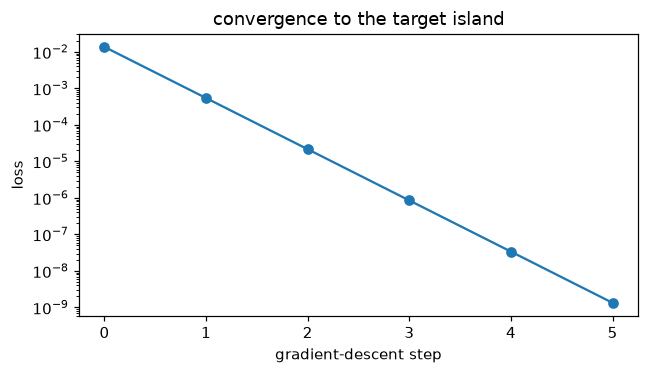

In [4]:
epsilons, losses = zip(*history)
figure, axis = plt.subplots(figsize=(6, 3.5), dpi=110)
axis.semilogy(range(len(losses)), losses, marker="o")
axis.set_xlabel("gradient-descent step")
axis.set_ylabel("loss")
axis.set_title("convergence to the target island")
figure.tight_layout()

The optimizer recovers the amplitude in a handful of steps because the
objective is smooth and the gradient is exact. Real inference problems add
noise, regularization, and identifiability questions. Keep the
[gradient checklist](../physics/differentiability.md#validate-every-gradient)
in force for every new objective, and prefer smooth metrics over
critical-point counts.